**SVM**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

data = pd.read_csv("heart.csv")
selected_features = ["age", "sex", "cp", "trestbps", "chol"]
X = data[selected_features]
y = data["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred)
svm_precision = precision_score(y_test, y_pred)
svm_recall = recall_score(y_test, y_pred)
svm_f1 = f1_score(y_test, y_pred)

print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1 Score:", svm_f1)


Accuracy: 0.7914691943127962
Precision: 0.8476190476190476
Recall: 0.7606837606837606
F1 Score: 0.8018018018018018


 **KNN**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

data = pd.read_csv("heart.csv")
selected_features = ["age", "sex", "cp", "trestbps", "chol"]
X = data[selected_features]
y = data["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred)
knn_precision = precision_score(y_test, y_pred)
knn_recall = recall_score(y_test, y_pred)
knn_f1 = f1_score(y_test, y_pred)

print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1 Score:", knn_f1)


Accuracy: 0.8341232227488151
Precision: 0.8727272727272727
Recall: 0.8205128205128205
F1 Score: 0.8458149779735683


**GRADIENT**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

data = pd.read_csv("heart.csv")
selected_features = ["age", "sex", "cp", "trestbps", "chol"]
X = data[selected_features]
y = data["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, y_pred)
gb_precision = precision_score(y_test, y_pred)
gb_recall = recall_score(y_test, y_pred)
gb_f1 = f1_score(y_test, y_pred)

print("Accuracy:", gb_accuracy)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1 Score:", gb_f1)


Accuracy: 0.8862559241706162
Precision: 0.9043478260869565
Recall: 0.8888888888888888
F1 Score: 0.896551724137931


**SVM WITH JFO**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.over_sampling import SMOTE

data = pd.read_csv("heart.csv")
data.fillna(data.mean(), inplace=True)

X = data.drop(columns=["target"])
y = data["target"]

chi2_selector = SelectKBest(chi2, k=5)
X_selected = chi2_selector.fit_transform(X, y)
selected_features = X.columns[chi2_selector.get_support()].tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

def objective_function(params):
    C, gamma = params
    model = SVC(C=C, gamma=gamma, kernel='rbf')
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    return np.mean(scores)

class JellyfishOptimization:
    def __init__(self, objective_function, bounds, population_size, iterations, alpha=3, beta=0.1):
        self.objective_function = objective_function
        self.bounds = np.array(bounds)
        self.population_size = population_size
        self.iterations = iterations
        self.alpha = alpha
        self.beta = beta
        self.population = None
        self.best_solution = None
        self.best_score = float("-inf")

    def initialize_population(self):
        self.population = np.random.uniform(self.bounds[:, 0], self.bounds[:, 1], (self.population_size, len(self.bounds)))

    def evaluate_population(self):
        fitness = np.array([self.objective_function(ind) for ind in self.population])
        best_index = np.argmax(fitness)
        if fitness[best_index] > self.best_score:
            self.best_score = fitness[best_index]
            self.best_solution = self.population[best_index]
        return fitness

    def move_jellyfish(self, fitness):
        new_population = np.copy(self.population)
        for i in range(self.population_size):
            if np.random.rand() < 0.5:
                r1, r2 = np.random.choice(self.population_size, 2, replace=False)
                direction = self.population[r1] - self.population[r2]
                new_position = self.population[i] + self.alpha * np.random.rand() * direction
            else:
                jellyfish_mean = np.mean(self.population, axis=0)
                direction = jellyfish_mean - self.population[i]
                new_position = self.population[i] + self.beta * np.random.rand() * direction
            new_population[i] = np.clip(new_position, self.bounds[:, 0], self.bounds[:, 1])
        return new_population

    def optimize(self):
        self.initialize_population()
        for _ in range(self.iterations):
            fitness = self.evaluate_population()
            self.population = self.move_jellyfish(fitness)
        return self.best_solution

bounds = [(0.1, 1000), (0.001, 1)]

jellyfish = JellyfishOptimization(objective_function, bounds, population_size=10, iterations=50)
best_params = jellyfish.optimize()

svm_model = SVC(C=best_params[0], gamma=best_params[1], kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

cv_scores = cross_val_score(svm_model, X_train, y_train, cv=5)

jfo_accuracy = accuracy_score(y_test, y_pred)
jfo_precision = precision_score(y_test, y_pred)
jfo_recall = recall_score(y_test, y_pred)
jfo_f1 = f1_score(y_test, y_pred)

print("Selected Features:", selected_features)
print("Accuracy:", jfo_accuracy)
print("Precision:", jfo_precision)
print("Recall:", jfo_recall)
print("F1 Score:", jfo_f1)
print("Cross-Validation Scores:", cv_scores)
print("Mean Cross-Validation Accuracy:", np.mean(cv_scores))


Selected Features: ['cp', 'thalach', 'exang', 'oldpeak', 'ca']
Accuracy: 0.95260663507109
Precision: 0.9349593495934959
Recall: 0.9829059829059829
F1 Score: 0.9583333333333334
Cross-Validation Scores: [0.92307692 0.92857143 0.9702381  0.95833333 0.94047619]
Mean Cross-Validation Accuracy: 0.9441391941391941


SVM:
  Accuracy: 0.7914691943127962
  Precision: 0.8476190476190476
  Recall: 0.7606837606837606
  F1 Score: 0.8018018018018018

KNN:
  Accuracy: 0.8341232227488151
  Precision: 0.8727272727272727
  Recall: 0.8205128205128205
  F1 Score: 0.8458149779735683

Gradient Boosting:
  Accuracy: 0.8862559241706162
  Precision: 0.9043478260869565
  Recall: 0.8888888888888888
  F1 Score: 0.896551724137931

SVM with JFO:
  Accuracy: 0.95260663507109
  Precision: 0.9349593495934959
  Recall: 0.9829059829059829
  F1 Score: 0.9583333333333334



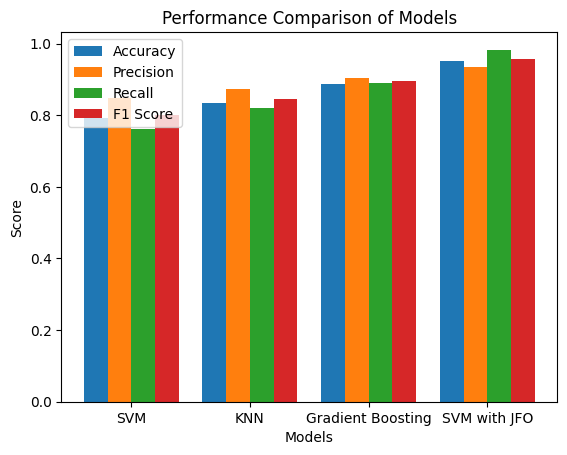

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = ['SVM', 'KNN', 'Gradient Boosting', 'SVM with JFO']
metrics = {
    'SVM': [svm_accuracy, svm_precision, svm_recall, svm_f1],
    'KNN': [knn_accuracy, knn_precision, knn_recall, knn_f1],
    'Gradient Boosting': [gb_accuracy, gb_precision, gb_recall, gb_f1],
    'SVM with JFO': [jfo_accuracy, jfo_precision, jfo_recall, jfo_f1]
}

for model, values in metrics.items():
    print(f"{model}:")
    print(f"  Accuracy: {values[0]}")
    print(f"  Precision: {values[1]}")
    print(f"  Recall: {values[2]}")
    print(f"  F1 Score: {values[3]}\n")

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots()
rects1 = ax.bar(x - 1.5*width, [metrics[m][0] for m in models], width, label='Accuracy')
rects2 = ax.bar(x - 0.5*width, [metrics[m][1] for m in models], width, label='Precision')
rects3 = ax.bar(x + 0.5*width, [metrics[m][2] for m in models], width, label='Recall')
rects4 = ax.bar(x + 1.5*width, [metrics[m][3] for m in models], width, label='F1 Score')

ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.set_title("Performance Comparison of Models")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 69.6 MB/s eta 0:00:00


Writing app.py


ERROR:pyngrok.process.ngrok:t=2026-02-28T04:37:37+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-02-28T04:37:37+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-02-28T04:37:37+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.